# Notebook 02: Feature Engineering

**Project:** MAP Dryer AI  
**Purpose:** transform the deduplicated dryer dataset into a consistent, model-ready feature table for the soft-sensor workflow.

The notebook standardises key data types, builds a timestamp, prepares a complete-case modelling dataset, explores baseline relationships, and derives process-informed features.

## Inputs and outputs

- **Input:** `data/processed/dryerMAP_prototype_deduplicated.xlsx` (created in Notebook 01)
- **Output:** `data/processed/dryerMAP_prototype_processed.csv`
- **Figure outputs:** `figures/02_Feature_Engineering/`

## Reading guide

All transformations are applied in sequence. The final export is intended for Notebook 03, where soft-sensor models are trained and evaluated.

## 1. Import analysis libraries

Load the libraries needed for data handling, visualisation, statistics, and the downstream modelling workflow.

In [112]:
from pathlib import Path
import platform
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats
import openpyxl
import statsmodels


## 2. Load the deduplicated dataset

Find the project root dynamically, then load the output of Notebook 01. The dataset structure is displayed before any further transformation.

In [113]:
SRC_DIR = next(candidate / "src" for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").is_dir())
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from data.project_paths import find_project_root
PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "02_Feature_Engineering"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_deduplicated.xlsx"
dryerMAP = pd.read_excel(DATA_PATH)
dryerMAP.info()

<class 'pandas.DataFrame'>
RangeIndex: 1082 entries, 0 to 1081
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1082 non-null   datetime64[us]
 1   time                       1082 non-null   str           
 2   dryer_air_temperature      1081 non-null   float64       
 3   cooler_air_temperature     1078 non-null   float64       
 4   air_flow_rate              1081 non-null   float64       
 5   wet_product_feed_rate      1081 non-null   float64       
 6   product_inlet_temperature  1082 non-null   float64       
 7   residence_time             1081 non-null   float64       
 8   vacuum                     1079 non-null   float64       
 9   steam_pressure             1079 non-null   float64       
 10  fan_speed                  1076 non-null   float64       
 11  product_density            1078 non-null   float64       
 12  final_product_tem

## 3. Standardise data types and create a timestamp

Convert the date, time, target, and selected process variables to suitable numeric or temporal types. Combining the date and time fields creates a single chronological `timestamp` for later time-aware analysis.

In [115]:
dryerMAP["date"] = pd.to_datetime(
    dryerMAP["date"],
    dayfirst=True
)

In [116]:
dryerMAP["time"] = pd.to_datetime(
    dryerMAP["time"],
    format="%H:%M:%S"
).dt.time

In [117]:
dryerMAP["timestamp"] = pd.to_datetime(
    dryerMAP["date"].dt.strftime("%Y-%m-%d") + " " + dryerMAP["time"].astype(str)
)

In [118]:
dryerMAP["product_density"] = pd.to_numeric(
    dryerMAP["product_density"],
    errors="coerce"
)

In [ ]:
dryerMAP["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP["final_moisture_h₂o"],
    errors="coerce"
)

In [121]:
cols = [
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed"
]

dryerMAP[cols] = dryerMAP[cols].astype(float)

## 4. Verify the transformed dataset

Review the resulting column types and non-null counts after standardisation. This confirms that the fields used in the next steps have the expected representation.

In [122]:
dryerMAP.info()

<class 'pandas.DataFrame'>
RangeIndex: 1082 entries, 0 to 1081
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1082 non-null   datetime64[us]
 1   time                       1082 non-null   object        
 2   dryer_air_temperature      1081 non-null   float64       
 3   cooler_air_temperature     1078 non-null   float64       
 4   air_flow_rate              1081 non-null   float64       
 5   wet_product_feed_rate      1081 non-null   float64       
 6   product_inlet_temperature  1082 non-null   float64       
 7   residence_time             1081 non-null   float64       
 8   vacuum                     1079 non-null   float64       
 9   steam_pressure             1079 non-null   float64       
 10  fan_speed                  1076 non-null   float64       
 11  product_density            1078 non-null   float64       
 12  final_product_tem

## 5. Create the complete-case modelling table

Rows with missing values are removed to form `dryerMAP_model`. The printed counts make the impact of this modelling choice explicit.

In [123]:
print(f"Original dataset: {len(dryerMAP)} rows")

dryerMAP_model = dryerMAP.dropna(subset=dryerMAP.columns.tolist()).copy()

print(f"Clean dataset: {len(dryerMAP_model)} rows")

print(f"Rows removed: {len(dryerMAP)-len(dryerMAP_model)}")

Original dataset: 1082 rows
Clean dataset: 1051 rows
Rows removed: 31


## 6. Inspect distributions before modelling

A boxplot gives a quick visual check of scale, spread, and potential outliers across the available numerical variables.

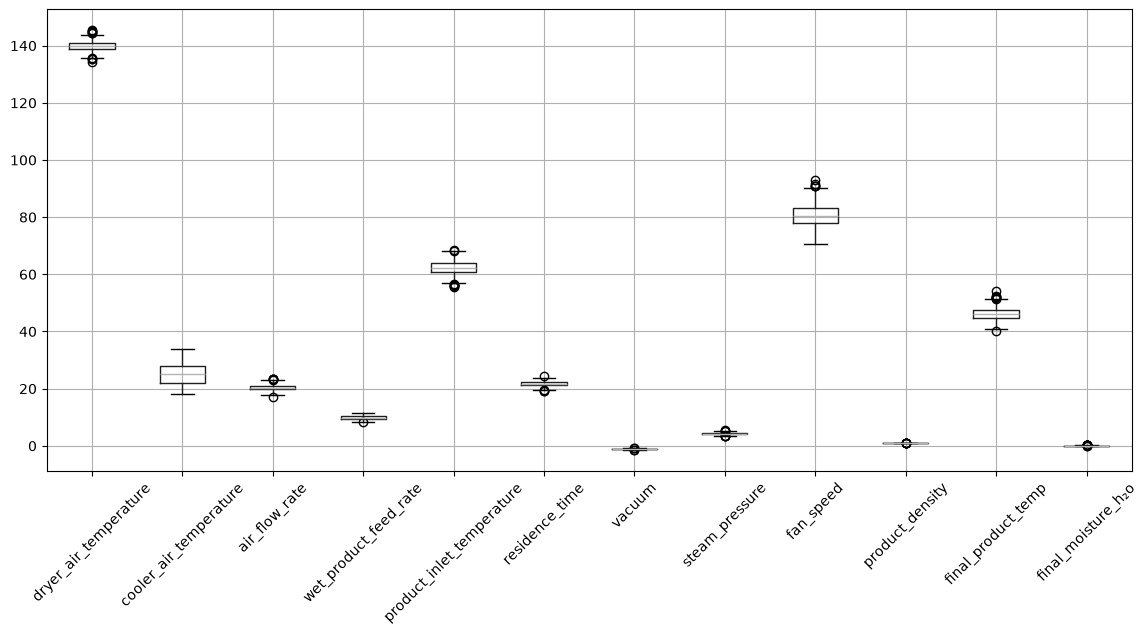

In [124]:
fig, ax = plt.subplots(figsize=(14, 6))
dryerMAP_model.boxplot(ax=ax, rot=45)
ax.set_title("MAP Dryer: Feature Distributions and Potential Outliers")
ax.set_xlabel("Feature")
ax.set_ylabel("Value")
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 7. Establish baseline correlations

Calculate and visualise Pearson correlations among numeric variables. This is exploratory evidence, not a claim of causation, and helps identify relationships worth examining during modelling.

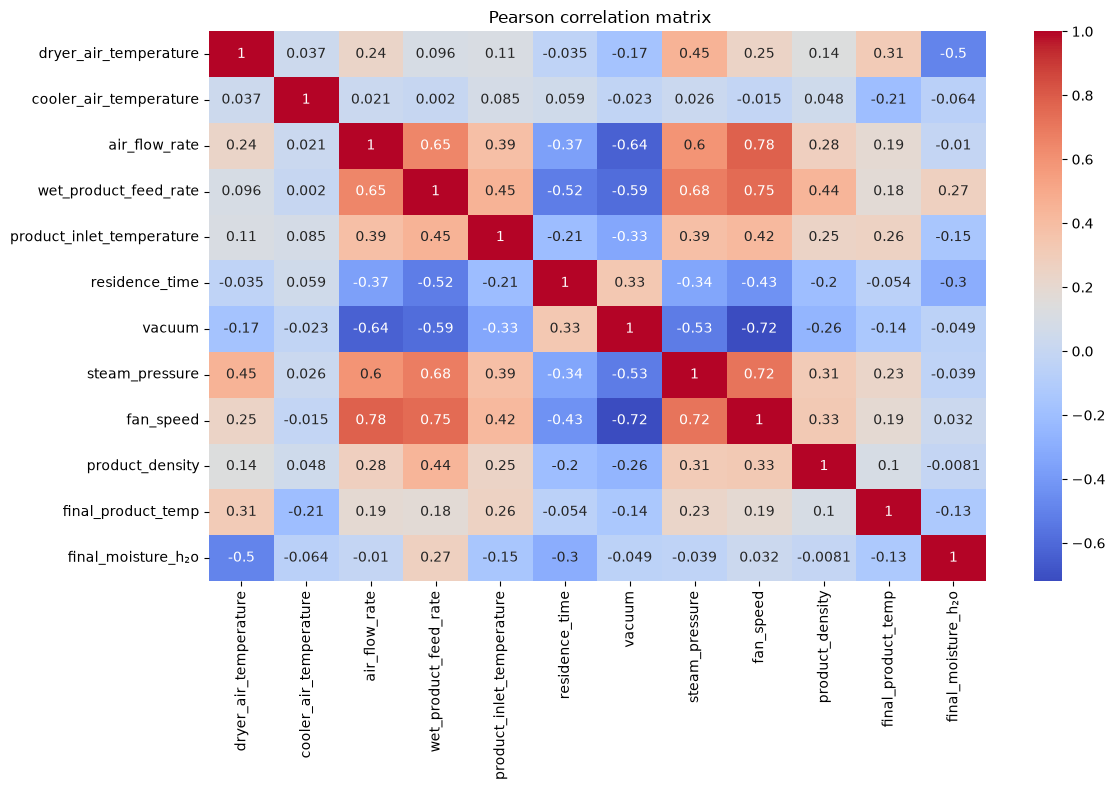

In [125]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dryerMAP_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("MAP Dryer: Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_pearson_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 8. Examine relationships with the quality target

Convert the final-moisture target to numeric form and rank its linear correlations with the available numeric variables. This provides a baseline before engineered features are added.

In [ ]:
target = next(c for c in dryerMAP.columns if "final_moisture" in c)

dryerMAP[target] = pd.to_numeric(
    dryerMAP[target].astype(str).str.replace("%", "", regex=False),
    errors="coerce",
)
corr_with_target = (
    dryerMAP.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

print(corr_with_target)

final_moisture_h₂o           1.000000
wet_product_feed_rate        0.262995
fan_speed                    0.031030
product_density             -0.010452
air_flow_rate               -0.011997
steam_pressure              -0.041569
vacuum                      -0.043935
cooler_air_temperature      -0.057715
final_product_temp          -0.129339
product_inlet_temperature   -0.149405
residence_time              -0.288368
dryer_air_temperature       -0.494168
Name: final_moisture_h₂o, dtype: float64


## 9. Create process-informed features

The following derived variables express useful process relationships:

- `temperature_drop`: dryer-air temperature minus final-product temperature
- `air_product_delta`: dryer-air temperature minus product-inlet temperature
- `air_per_feed`: air-flow rate per wet-product feed rate
- `steam_temp_interaction`: steam pressure multiplied by dryer-air temperature
- `heating_index`: residence time multiplied by dryer-air temperature

Each feature is created in a separate cell so the transformation remains easy to inspect and revise.

In [132]:
dryerMAP_model["temperature_drop"] = (
    dryerMAP_model['dryer_air_temperature']
    - dryerMAP_model['final_product_temp']
)

In [133]:
dryerMAP_model["air_product_delta"] = (
    dryerMAP_model["dryer_air_temperature"]
    - dryerMAP_model['product_inlet_temperature']
)

In [134]:
dryerMAP_model["air_per_feed"] = (
    dryerMAP_model['air_flow_rate']
    / dryerMAP_model['wet_product_feed_rate']
)

In [139]:
dryerMAP_model["steam_temp_interaction"] = (
    dryerMAP_model['steam_pressure']
    * dryerMAP_model['dryer_air_temperature']
)

In [135]:
dryerMAP_model["heating_index"] = (
    dryerMAP_model["residence_time"]
    * dryerMAP_model["dryer_air_temperature"]
)

## 10. Inspect the engineered feature table

List the final columns and preview the first records to confirm that the derived variables were added as intended.

In [144]:
dryerMAP_model.columns.tolist()

['date',
 'time',
 'dryer_air_temperature',
 'cooler_air_temperature',
 'air_flow_rate',
 'wet_product_feed_rate',
 'product_inlet_temperature',
 'residence_time',
 'vacuum',
 'steam_pressure',
 'fan_speed',
 'product_density',
 'final_product_temp',
 'final_moisture_h₂o',
 'timestamp',
 'temperature_drop',
 'air_product_delta',
 'air_per_feed',
 'heating_index',
 'steam_temp_interaction']

In [136]:
dryerMAP_model.head()

,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,heating_index
0,2026-05-01,01:00:00,140.8,18.0,19.95,9.73,61.1,23.08,-0.98,4.20,78.9,1.021,45.6,0.081,2026-05-01 01:00:00,95.2,79.7,2.050360,3249.664
1,2026-05-01,03:00:00,139.6,22.8,19.94,9.82,61.2,21.95,-1.00,4.27,79.7,1.027,43.8,0.115,2026-05-01 03:00:00,95.8,78.4,2.030550,3064.220
2,2026-05-01,05:00:00,140.4,23.6,20.98,9.62,63.2,21.79,-1.01,4.13,82.1,1.026,43.1,0.084,2026-05-01 05:00:00,97.3,77.2,2.180873,3059.316
3,2026-05-01,07:00:00,138.7,24.7,20.05,10.31,64.3,20.94,-1.13,4.13,83.1,1.024,44.5,0.105,2026-05-01 07:00:00,94.2,74.4,1.944714,2904.378
4,2026-05-01,09:00:00,141.0,26.7,19.72,10.11,63.0,21.89,-0.98,4.66,82.8,1.030,46.5,0.083,2026-05-01 09:00:00,94.5,78.0,1.950544,3086.490


## 11. Visualise and rank engineered features

Plot each engineered feature against final moisture, then rank all numeric features by the absolute size of their Pearson correlation with the target. These views help prioritise candidates for the soft-sensor models.

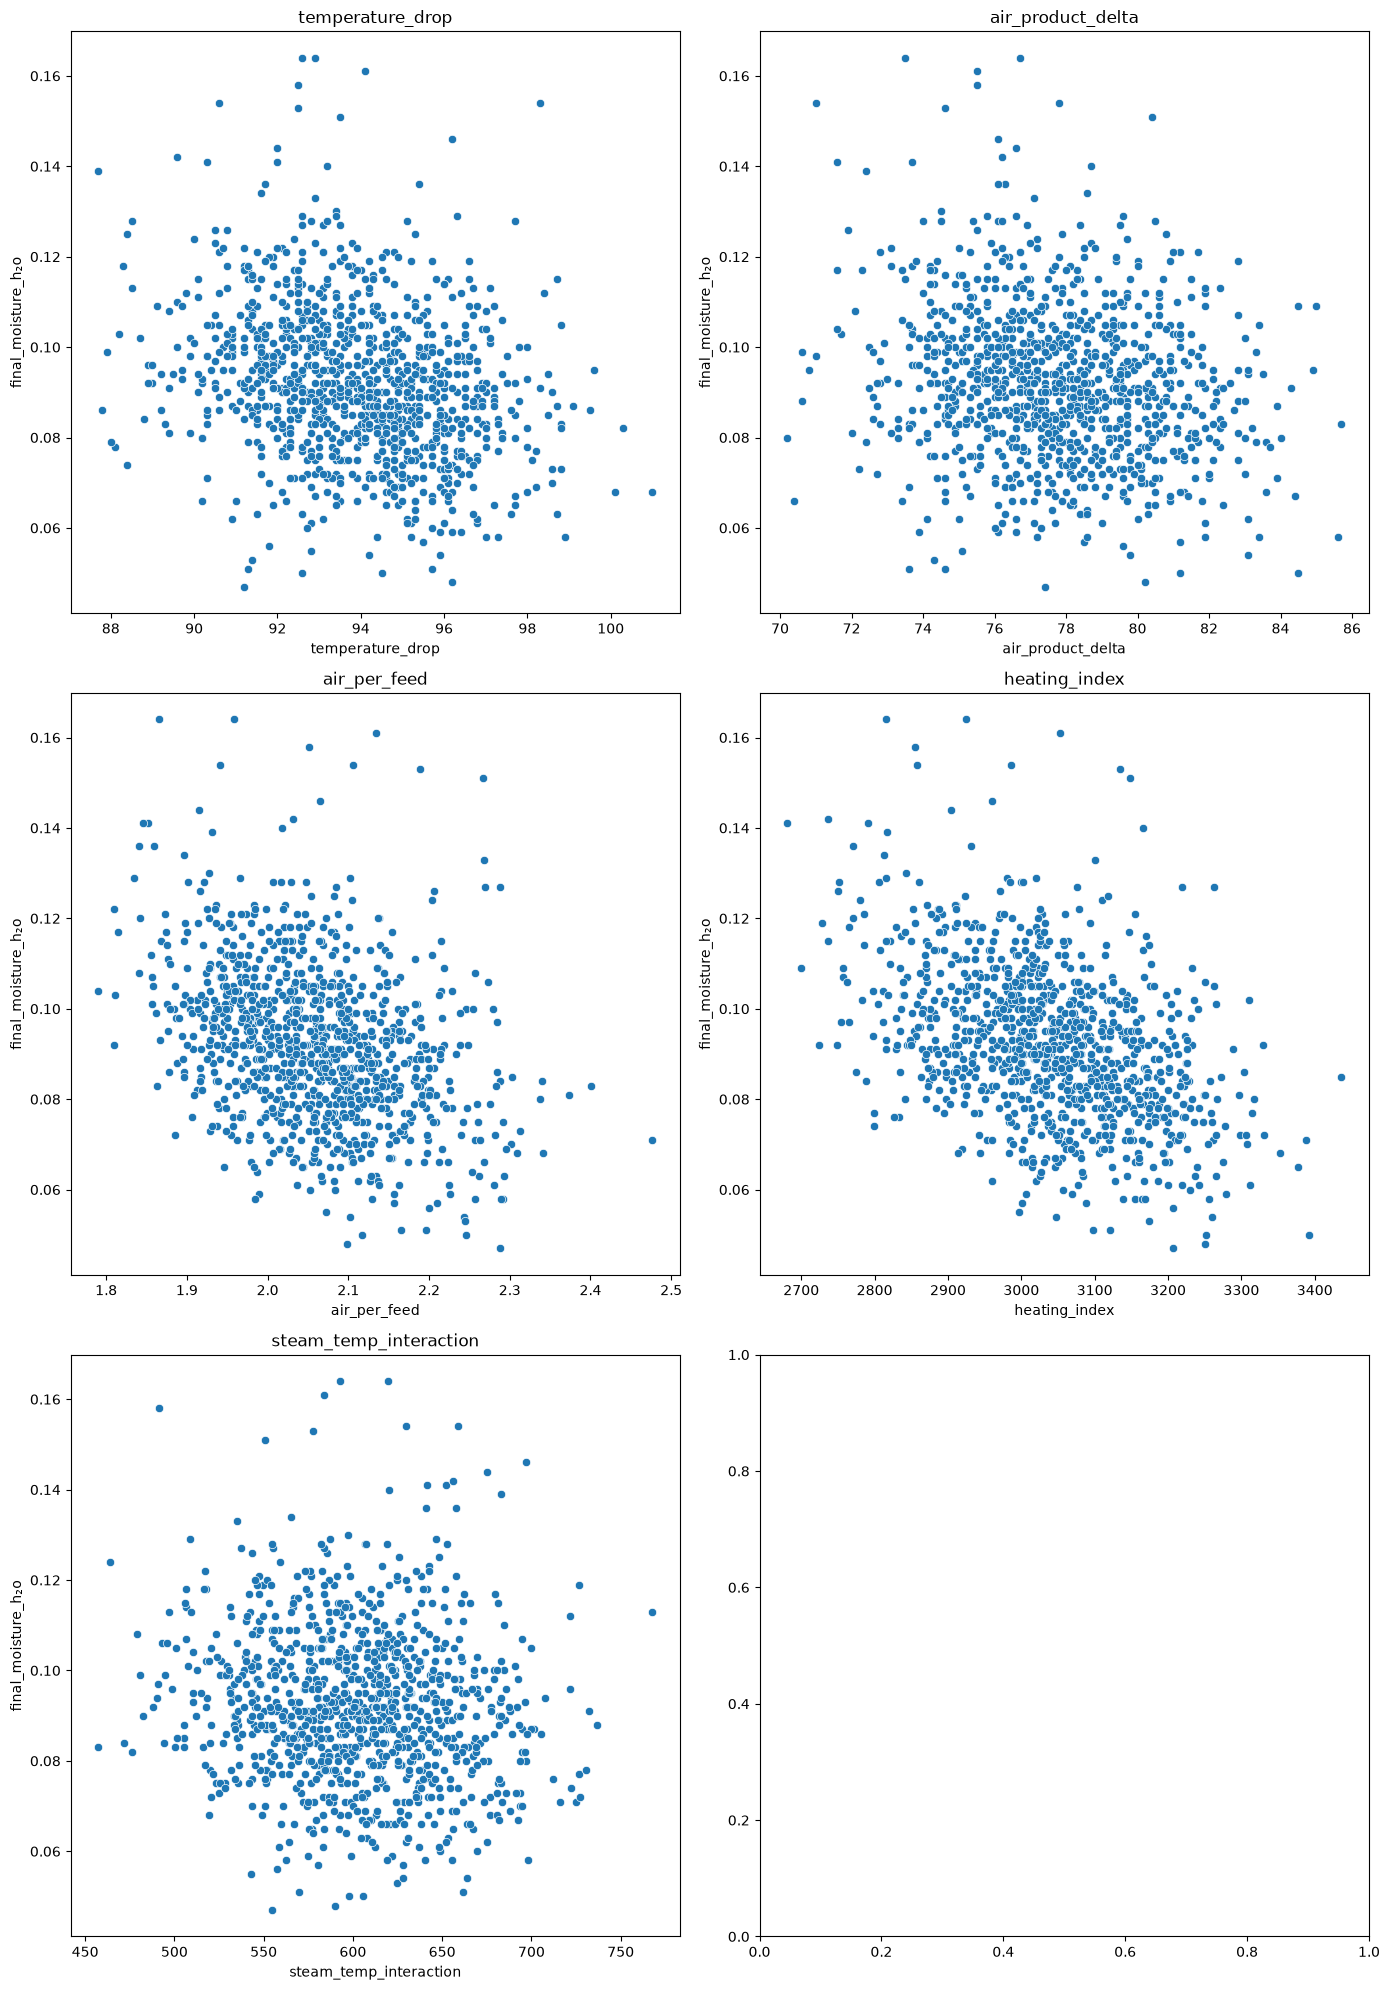

In [140]:
engineered_features = [
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "heating_index",
    "steam_temp_interaction"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 20))
fig.suptitle("MAP Dryer: Engineered Features vs. Final Moisture", y=1.01)
axes = axes.flatten()

for ax, feature in zip(axes, engineered_features):
    sns.scatterplot(
        data=dryerMAP_model,
        x=feature,
        y="final_moisture_h₂o",
        ax=ax
    )
    display_name = feature.replace("_", " ").title()
    ax.set_title(f"{display_name} vs. Final Moisture")
    ax.set_xlabel(display_name)
    ax.set_ylabel("Final Moisture (H?O)")

for ax in axes[len(engineered_features):]:
    ax.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(
    FIGURE_OUTPUT_DIR / "03_engineered_features_vs_final_moisture.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [141]:
corr = dryerMAP_model.corr(numeric_only=True)["final_moisture_h₂o"]

corr_df = (
    corr.drop("final_moisture_h₂o")
        .to_frame(name="Correlation")
)

corr_df["Absolute Correlation"] = corr_df["Correlation"].abs()

corr_df = corr_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

display(corr_df)

,Correlation,Absolute Correlation
dryer_air_temperature,-0.496503,0.496503
heating_index,-0.434197,0.434197
air_per_feed,-0.352908,0.352908
residence_time,-0.296075,0.296075
wet_product_feed_rate,0.269246,0.269246
temperature_drop,-0.263731,0.263731
air_product_delta,-0.192762,0.192762
product_inlet_temperature,-0.150712,0.150712
final_product_temp,-0.130776,0.130776
steam_temp_interaction,-0.110074,0.110074


## 12. Export the model-ready dataset

Write the completed feature table to the processed-data directory. This CSV is the hand-off artifact for the soft-sensor modelling notebook.

In [143]:
dryerMAP_model.to_csv(
    "../data/processed/dryerMAP_prototype_processed.csv",
    index=False
)

## Next step

Continue with **Notebook 03: Model 1: Soft Sensor** to train and evaluate moisture-prediction models using this processed dataset.